<a href="https://colab.research.google.com/github/elfaijaabderazak833-hub/data-analyst-portfolio/blob/main/sales-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [37]:
df=pd.read_csv('market.csv')
df.head(5)

,customer name,Order ID,Order Date,Product,Category,Quantity,Price,Payment method,Status
0,Alice Johnson,ORD1001,2024-01-15,Laptop,Electronics,1,899.99,Credit Card,Delivered
1,Bob Smith,ORD1002,2024-01-16,Office Chair,Furniture,2,149.50,PayPal,Shipped
2,Carol Davis,ORD1003,2024-01-16,Desk Lamp,Lighting,1,29.99,Credit Card,Delivered
3,David Brown,ORD1004,2024-01-17,Keyboard,Electronics,3,45.99,Debit Card,Pending
4,Emma Wilson,ORD1005,2024-01-18,Coffee Mug,Kitchen,5,12.99,PayPal,Delivered


In [38]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer name   100 non-null    object 
 1   Order ID        100 non-null    object 
 2   Order Date      100 non-null    object 
 3   Product         100 non-null    object 
 4   Category        100 non-null    object 
 5   Quantity        100 non-null    int64  
 6   Price           100 non-null    float64
 7   Payment method  100 non-null    object 
 8   Status          100 non-null    object 
dtypes: float64(1), int64(1), object(7)
memory usage: 7.2+ KB
None


In [39]:
print(df.shape)

(100, 9)


In [40]:
df.columns

Index(['customer name', 'Order ID', 'Order Date', 'Product', 'Category',
       'Quantity', 'Price', 'Payment method', 'Status'],
      dtype='object')

In [41]:
df.describe()

,Quantity,Price
count,100.000000,100.000000
mean,2.370000,54.135200
std,2.285903,108.261245
min,1.000000,2.490000
25%,1.000000,12.990000
50%,1.500000,22.990000
75%,3.000000,45.990000
max,15.000000,899.990000


In [42]:
df.columns=df.columns.str.strip().str.lower().str.replace(' ', '_')
df.columns

Index(['customer_name', 'order_id', 'order_date', 'product', 'category',
       'quantity', 'price', 'payment_method', 'status'],
      dtype='object')

In [43]:
df['order_date']=pd.to_datetime(df['order_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_name   100 non-null    object        
 1   order_id        100 non-null    object        
 2   order_date      100 non-null    datetime64[ns]
 3   product         100 non-null    object        
 4   category        100 non-null    object        
 5   quantity        100 non-null    int64         
 6   price           100 non-null    float64       
 7   payment_method  100 non-null    object        
 8   status          100 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 7.2+ KB


In [44]:
df.isnull().sum()

,0
customer_name,0
order_id,0
order_date,0
product,0
category,0
quantity,0
price,0
payment_method,0
status,0


In [45]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
95,False
96,False
97,False
98,False


In [46]:
df['revenues']=df['quantity']*df['price']

In [47]:
df.head(5)

,customer_name,order_id,order_date,product,category,quantity,price,payment_method,status,revenues
0,Alice Johnson,ORD1001,2024-01-15,Laptop,Electronics,1,899.99,Credit Card,Delivered,899.99
1,Bob Smith,ORD1002,2024-01-16,Office Chair,Furniture,2,149.50,PayPal,Shipped,299.00
2,Carol Davis,ORD1003,2024-01-16,Desk Lamp,Lighting,1,29.99,Credit Card,Delivered,29.99
3,David Brown,ORD1004,2024-01-17,Keyboard,Electronics,3,45.99,Debit Card,Pending,137.97
4,Emma Wilson,ORD1005,2024-01-18,Coffee Mug,Kitchen,5,12.99,PayPal,Delivered,64.95


In [48]:
sales_by_category=df.groupby('category')['revenues'].sum().sort_values(ascending=False)

In [49]:
print(sales_by_category.head(5))

category
Electronics    2216.76
Furniture      1078.94
Kitchen         801.49
Home Decor      667.26
Accessories     549.87
Name: revenues, dtype: float64


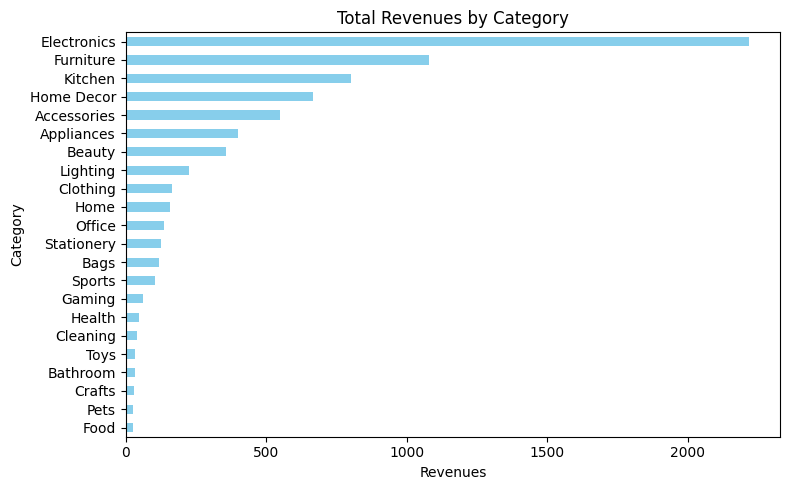

In [50]:
sales_by_category.sort_values().plot(kind='barh', figsize=(8,5), color="skyblue")
plt.title('Total Revenues by Category')
plt.xlabel('Revenues')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

## نتائج تحليل المبيعات

**أهم 3 رؤى:**
1. **Electronics** هي أعلى فئة بالإيرادات، حوالي 2200 ريال.
2. أعلى 5 فئات تشكل معظم المبيعات، والباقي ضعيف جداً.
3. فئات مثل Food و Pets و Crafts تحتاج مراجعة.

**التوصية:**
التركيز على Electronics و Kitchen و Home Decor في التسويق.